In [62]:
import pandas as pd #https://www.youtube.com/watch?v=dQw4w9WgXcQ
import sklearn.metrics as metrics#confusion matrix
from sklearn.metrics import confusion_matrix#eda
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC #main model
from sklearn.metrics import accuracy_score#eda
from matplotlib import pyplot as plt#eda
from sklearn.feature_extraction.text import TfidfVectorizer as vectorizer #ubah entahlah biar jadi angka gitu
import seaborn as sb #sns be damned we are using sb
import re #basically special characters lul
import nltk #language stuff
from nltk.corpus import stopwords

#nltk.download('stopwords') #comment out when already installed

In [63]:
dataeng=pd.read_csv('nonoword.csv')#no saying nono words!
dataeng.head() #give data head

,is_offensive,text
0,0,Then go to the village pump and suggest they c...
1,1,ANTI GREEK NATIONALIS -WIKIPEDIA \n\nHi Alexik...
2,1,Dis hoe wasnt dis violent on Lottery Ticket 😂😂
3,0,It is better for Atabay not helping the banned...
4,0,"""is in CamelCase. """"SiCKO"""" is not CamelCase,..."


In [64]:
dataindo1 = pd.read_csv("bahasakasar.csv", encoding='latin-1')
dataindo1["Label"] = dataindo1["Label"].replace({2:1,1:0})# change label so 1 is offensive and 0 is not
dataindo1 = dataindo1.rename(columns={
    "Label": "is_offensive",
    "Tweet": "text"
}) #rename columns to match the other dataset
dataindo2 = pd.read_csv("kasar2.csv", encoding='latin-1')
dataindo2['VALUE'] = dataindo2['VALUE'].map({
    'Negative': 1,
    'Positive': 0
})
dataindo2 = dataindo2.rename(columns={
    "VALUE": "is_offensive",
    "Tweets": "text"
}) #rename columns to match the other dataset
dataindo = pd.concat([dataindo1, dataindo2], ignore_index=True) #combine the two datasets
dataindo.head()#give data head

,is_offensive,text
0,1,- Dia sendiri yang ngiklanin promo cashback di...
1,1,- disaat semua cowok berusaha melacak perhatia...
2,1,- kampret kan kalo typo-nya di email kantor ke...
3,1,"- Mending makan disini lebih murah, buang-buan..."
4,1,/biarin oppa masukim vibrator ke memek/ oppa k...


In [65]:
def cleaneng(text): #to clean the dataset from the stuff it cannot read
    text=re.sub(r'[^a-zA-Z\s]','',text)#special characters
    text=text.lower()#lower case
    stop_words=set(stopwords.words('english'))#sets stop words to english
    words=text.split() #split the text into words
    words=[word for word in words if word not in stop_words]#remove stop words
    text= ' '.join(words) #recombine the words into a string
    return text

In [66]:
def cleanindo(text): #to clean the dataset from the stuff it cannot read
    text=re.sub(r'[^a-zA-Z\s]','',text)#special characters
    text=text.lower()#lower case
    stop_words=set(stopwords.words('indonesian'))#sets stop words to indonesian
    words=text.split() #split the text into words
    words=[word for word in words if word not in stop_words]#remove stop words
    text= ' '.join(words) #recombine the words into a string
    return text

In [67]:
dataeng['text']=dataeng['text'].astype(str).apply(cleaneng)#apply cleaning to dataset
dataeng.head()# give data head

,is_offensive,text
0,0,go village pump suggest change language rfc set
1,1,anti greek nationalis wikipedia hi alexikoua y...
2,1,dis hoe wasnt dis violent lottery ticket
3,0,better atabay helping banned vandals pushing pov
4,0,camelcase sicko camelcase camelcase rule r bal...


In [68]:
dataindo['text']=dataindo['text'].astype(str).apply(cleanindo)#apply cleaning to dataset
dataindo.head()#give data head

,is_offensive,text
0,1,ngiklanin promo cashback appnyan penggunaan ko...
1,1,disaat cowok berusaha melacak perhatian gue lo...
2,1,kampret kalo typonya email kantor gue ngerasa ...
3,1,mending makan murah buangbuang duit lo ntar ta...
4,1,biarin oppa masukim vibrator memek oppa masuki...


In [69]:
data=pd.concat([dataeng,dataindo])#gabungin bindo sama beng
data = data.sample(frac=1).reset_index(drop=True)#shuffle dataset biar pas ditrain g bias satu bahasa
x=data['text'] #x is text
y=data['is_offensive'] #y is is_offensive
data.head()#give data head

,is_offensive,text
0,0,person specialise lawlegal matters
1,0,looks like content dispute dont think im best ...
2,0,floppy
3,0,agree concept semi protection straw poll passe...
4,1,im going track going track horrible violent th...


In [70]:
x_train, x_test, y_train, y_test = train_test_split(data['text'], y, test_size=0.2, random_state=42)
vector = vectorizer(max_features=5000, analyzer='char', ngram_range=(3,5)) #vectorizer to convert text to numerical
x_train_vector = vector.fit_transform(x_train) #fit the vectorizer to the training data and transform it into a matrix of token counts (autogenerated comment)
x_test_vector = vector.transform(x_test)

In [71]:
model=LinearSVC() #pake linear svc dibanding model yang lain soalnya lebih bagus sama cepet
model.fit(x_train_vector, y_train) #model fitting to training data
print(accuracy_score(y_test, model.predict(x_test_vector)))#0.9475636441265944
print(accuracy_score(y_train, model.predict(x_train_vector)))#0.9546936202178462



C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


0.94831082884133
0.9540811901664499


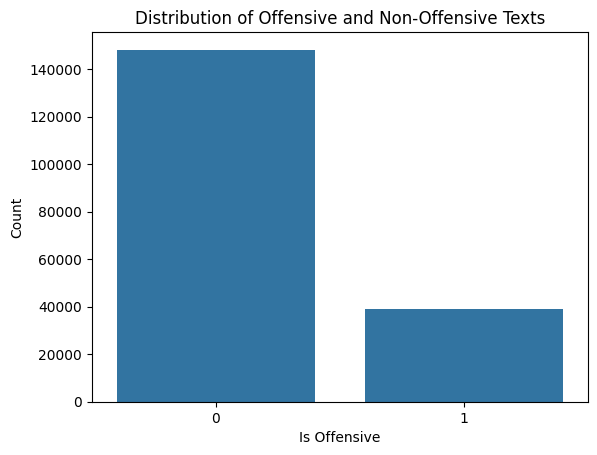

In [72]:
#plot
sb.countplot(x=data['is_offensive'])
plt.title('Distribution of Offensive and Non-Offensive Texts')
plt.xlabel('Is Offensive')
plt.ylabel('Count')
plt.show()

Text(0.5, 1.0, 'Confusion Matrix')

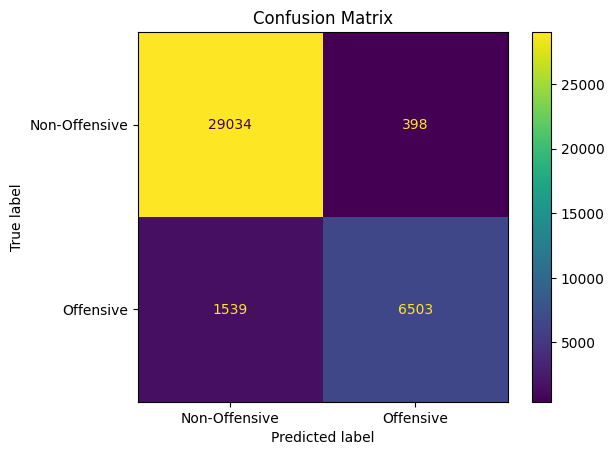

In [73]:
#confusion matrix
cm= metrics.confusion_matrix(y_test, model.predict(x_test_vector))
display=metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Offensive', 'Offensive'])
display.plot()
plt.title('Confusion Matrix')

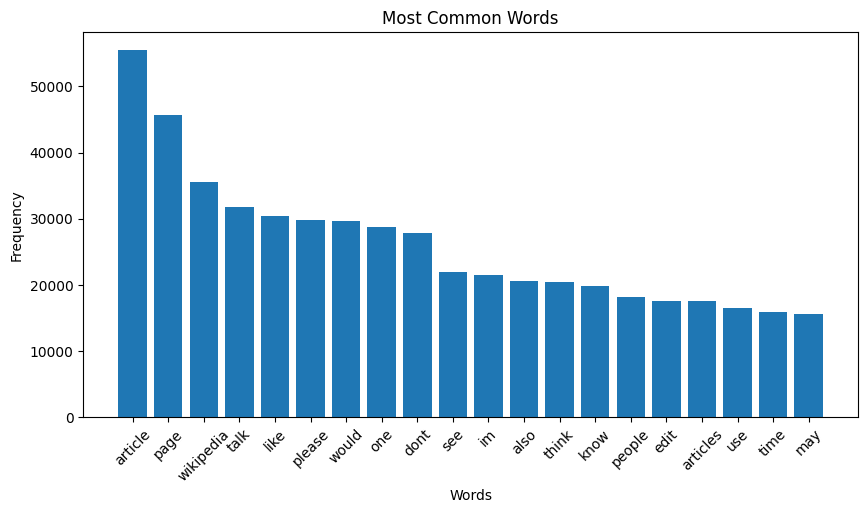

In [74]:
#most common words
from collections import Counter

all_words = ' '.join(data['text']).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title('Most Common Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

In [75]:
vector.fit(data['text']) #retrain data to read all
X_all = vector.transform(data['text'])
model.fit(X_all, data['is_offensive'])

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC()

In [76]:
import joblib #save model biar g retrain setiap kali run app
joblib.dump(model, 'model.pkl')
joblib.dump(vector, 'vectorizer.pkl')

['vectorizer.pkl']